In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df=pd.read_csv("AB_NYC_2019.csv")

In [9]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [11]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [15]:
df.shape

(48895, 16)

In [17]:
print("Duplicated:", df.duplicated().sum())

Duplicated: 0


In [19]:
print(df.isnull().sum())

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [21]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [23]:
# Handle missing values
#Cleaning individual columns
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

In [25]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [33]:
#Cleaning individual columns
df['name'] = df['name'].str.strip()
df['neighbourhood_group'] = df['neighbourhood_group'].str.strip().str.title()
df['neighbourhood'] = df['neighbourhood'].str.strip().str.title()

In [35]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [37]:
df['last_review'] = pd.to_datetime(df['last_review'])
df['price_per_night_category'] = pd.cut(
    df['price'],
    bins=[0, 50, 100, 200, 500, float('inf')],
    labels=['Budget', 'Mid', 'High', 'Luxury', 'Premium']
)

In [39]:
print(df.isnull().sum())

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
price_per_night_category             11
dtype: int64


In [41]:
print(df['price'].describe())

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


In [43]:
df = df[df['price'] > 0]

In [45]:
#Filter outliers entirely 
lower, upper = df['price'].quantile([0.01, 0.99])
df_filtered = df[(df['price'] >= lower) & (df['price'] <= upper)]

In [47]:
# Verify cleanup
print(df.isnull().sum())
print(f"\nRows before filtering: {len(df)}")
print(f"Rows after outlier filtering: {len(df_filtered)}")

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
price_per_night_category              0
dtype: int64

Rows before filtering: 48884
Rows after outlier filtering: 48017


In [49]:
print(df['last_review'].describe())

count                            38833
mean     2018-10-04 01:15:09.896222208
min                2011-03-28 00:00:00
25%                2018-07-08 00:00:00
50%                2019-05-19 00:00:00
75%                2019-06-23 00:00:00
max                2019-07-08 00:00:00
Name: last_review, dtype: object


In [51]:
df['last_review'] = pd.to_datetime(df['last_review'])
print(df['last_review'].describe())

count                            38833
mean     2018-10-04 01:15:09.896222208
min                2011-03-28 00:00:00
25%                2018-07-08 00:00:00
50%                2019-05-19 00:00:00
75%                2019-06-23 00:00:00
max                2019-07-08 00:00:00
Name: last_review, dtype: object


C:\Users\22257906\AppData\Local\Temp\ipykernel_3372\551144.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['last_review'] = pd.to_datetime(df['last_review'])


In [53]:
df['days_since_last_review'] = (pd.Timestamp.now() - df['last_review']).dt.days

C:\Users\22257906\AppData\Local\Temp\ipykernel_3372\4110626652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['days_since_last_review'] = (pd.Timestamp.now() - df['last_review']).dt.days


In [57]:
df['last_review'] = pd.to_datetime(df['last_review'])
print(df['last_review'].describe())  # should now show datetime64[ns]

df['days_since_last_review'] = (pd.Timestamp.now() - df['last_review']).dt.days

count                            38833
mean     2018-10-04 01:15:09.896222208
min                2011-03-28 00:00:00
25%                2018-07-08 00:00:00
50%                2019-05-19 00:00:00
75%                2019-06-23 00:00:00
max                2019-07-08 00:00:00
Name: last_review, dtype: object


C:\Users\22257906\AppData\Local\Temp\ipykernel_3372\971546103.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['last_review'] = pd.to_datetime(df['last_review'])
C:\Users\22257906\AppData\Local\Temp\ipykernel_3372\971546103.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['days_since_last_review'] = (pd.Timestamp.now() - df['last_review']).dt.days


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48884 entries, 0 to 48894
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48884 non-null  int64         
 1   name                            48884 non-null  object        
 2   host_id                         48884 non-null  int64         
 3   host_name                       48884 non-null  object        
 4   neighbourhood_group             48884 non-null  object        
 5   neighbourhood                   48884 non-null  object        
 6   latitude                        48884 non-null  float64       
 7   longitude                       48884 non-null  float64       
 8   room_type                       48884 non-null  object        
 9   price                           48884 non-null  int64         
 10  minimum_nights                  48884 non-null  int64         
 11  number_

In [61]:
df.to_csv('AB_NYC_2019_cleaned.csv', index=False)

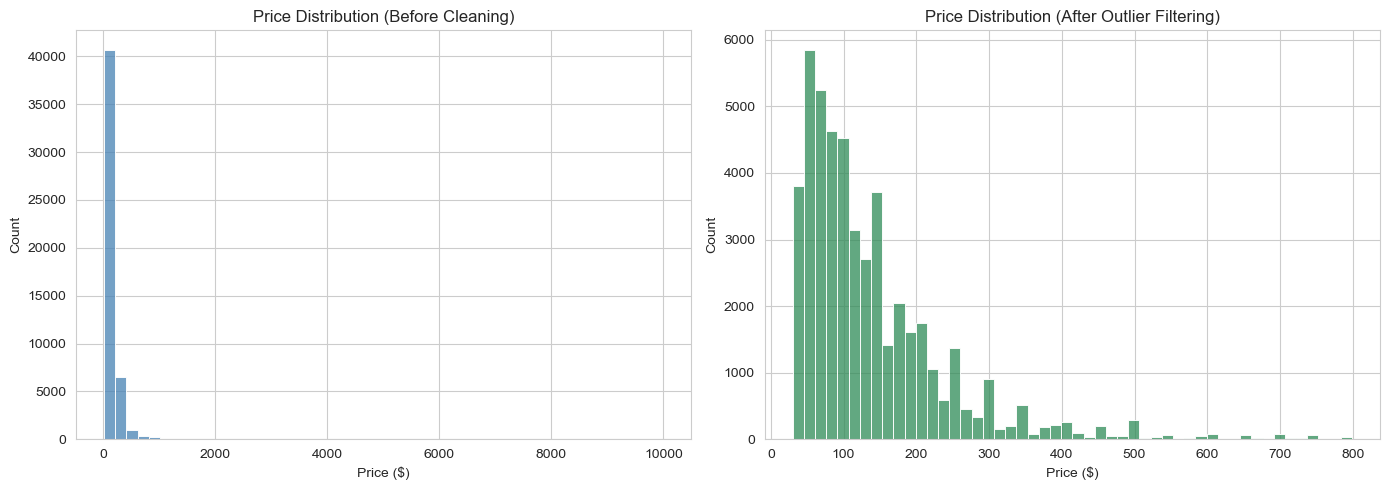

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: raw price distribution (with outliers)
sns.histplot(df['price'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution (Before Cleaning)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# After: filtered price distribution (outliers removed)
sns.histplot(df_filtered['price'], bins=50, ax=axes[1], color='seagreen')
axes[1].set_title('Price Distribution (After Outlier Filtering)')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('price_distribution_comparison.png', dpi=150)
plt.show()

In [63]:
sns.set_style('whitegrid')

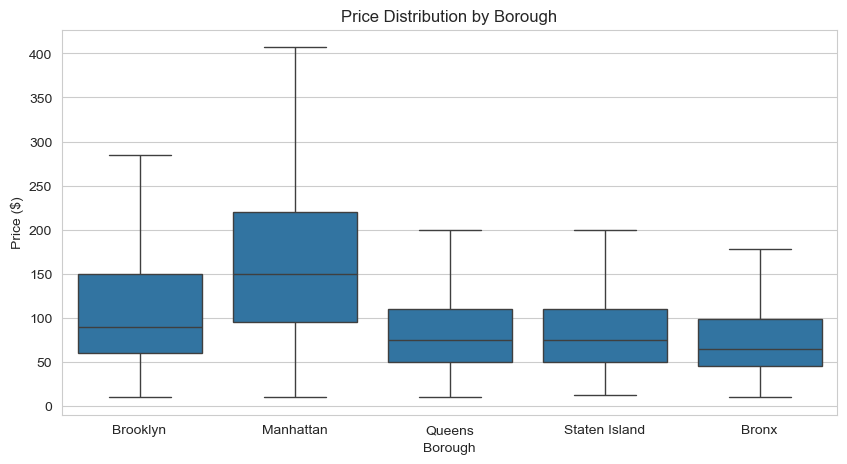

In [65]:
#1. Price by Borough 
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='neighbourhood_group', y='price', showfliers=False)
plt.title('Price Distribution by Borough')
plt.ylabel('Price ($)')
plt.xlabel('Borough')
plt.savefig('price_by_borough.png', dpi=150)
plt.show()

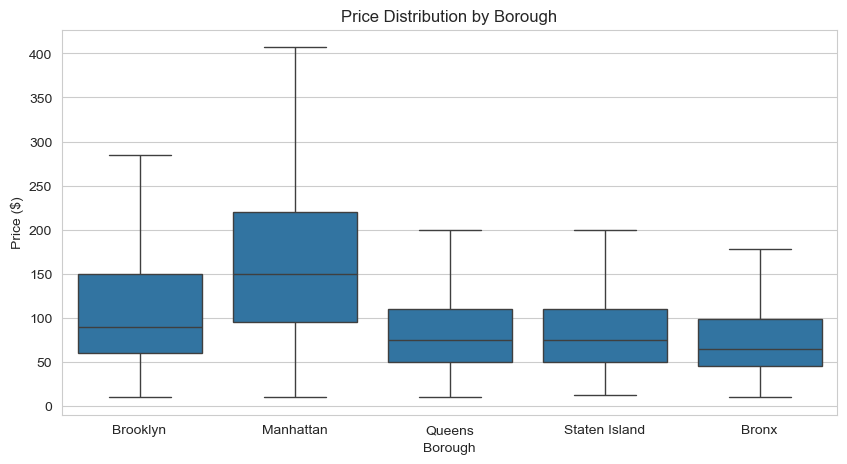

                           mean  median  count
neighbourhood_group                           
Manhattan            196.884903   150.0  21660
Brooklyn             124.438915    90.0  20095
Queens                99.517649    75.0   5666
Staten Island        114.812332    75.0    373
Bronx                 87.577064    65.0   1090


In [69]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='neighbourhood_group', y='price', showfliers=False)
plt.title('Price Distribution by Borough')
plt.ylabel('Price ($)')
plt.xlabel('Borough')
plt.savefig('price_by_borough.png', dpi=150)
plt.show()
print(df.groupby('neighbourhood_group')['price'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False))

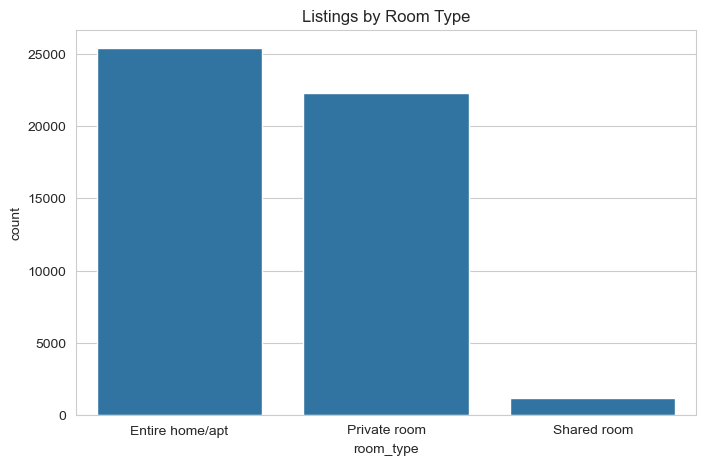

                       mean  median  count
room_type                                 
Entire home/apt  211.810918   160.0  25407
Private room      89.809131    70.0  22319
Shared room       70.248705    45.0   1158


In [71]:
#2. Room Type breakdown
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='room_type', order=df['room_type'].value_counts().index)
plt.title('Listings by Room Type')
plt.savefig('room_type_counts.png', dpi=150)
plt.show()

print(df.groupby('room_type')['price'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False))

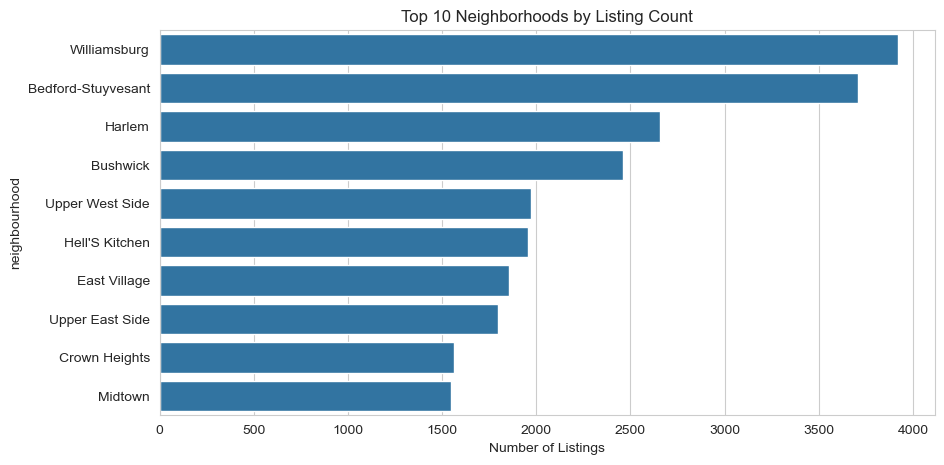

In [73]:
#3. Top neighborhoods by listing count
top_neighborhoods = df['neighbourhood'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index)
plt.title('Top 10 Neighborhoods by Listing Count')
plt.xlabel('Number of Listings')
plt.savefig('top_neighborhoods.png', dpi=150)
plt.show()


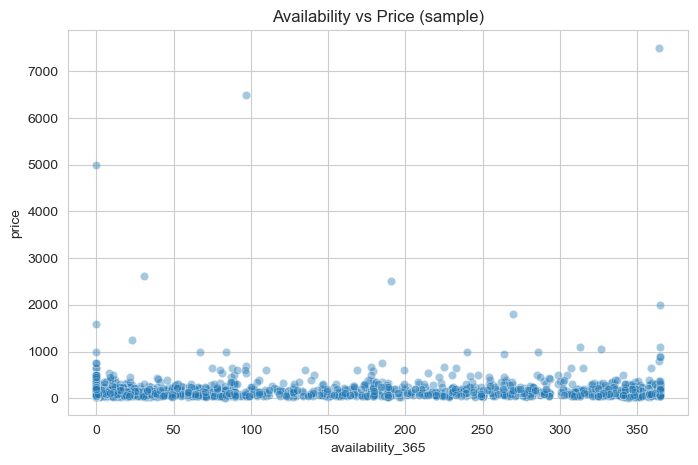

In [75]:
# 4. Availability vs Price relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(2000), x='availability_365', y='price', alpha=0.4)
plt.title('Availability vs Price (sample)')
plt.savefig('availability_vs_price.png', dpi=150)
plt.show()

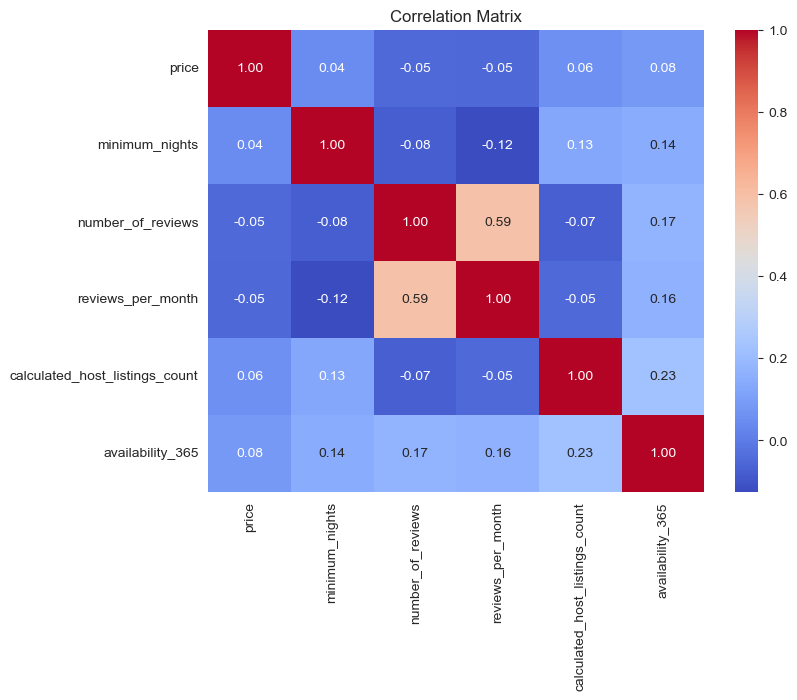

In [77]:
#5. Correlation heatmap (numeric features) 
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                 'calculated_host_listings_count', 'availability_365']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

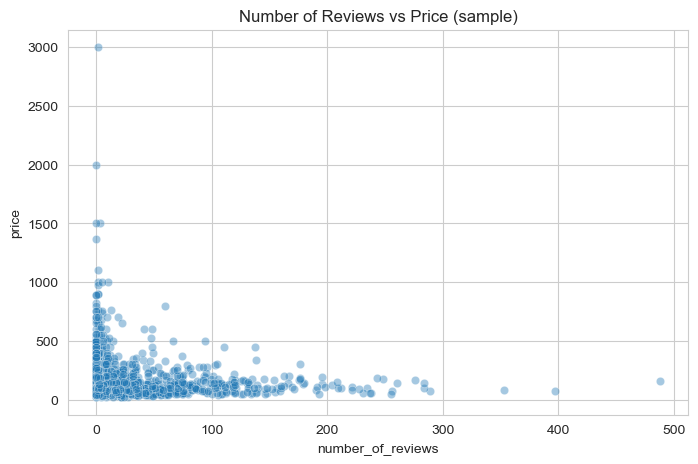

In [79]:
#6. Reviews vs Price 
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(2000), x='number_of_reviews', y='price', alpha=0.4)
plt.title('Number of Reviews vs Price (sample)')
plt.savefig('reviews_vs_price.png', dpi=150)
plt.show()

% of listings from hosts with 2+ listings: 33.9%


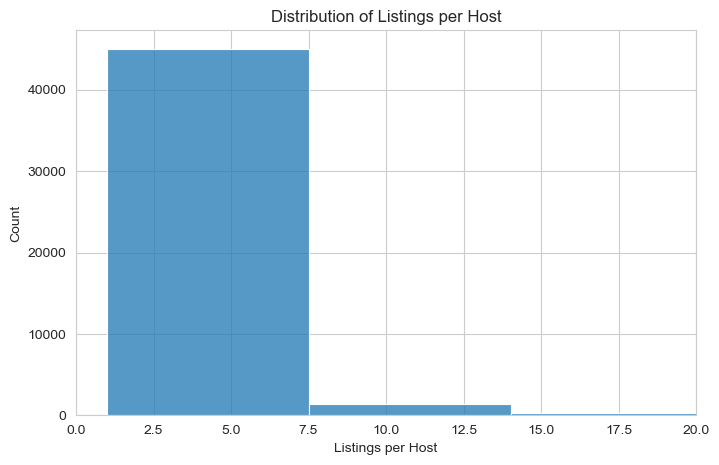

In [85]:
#Host concentration
host_counts = df['calculated_host_listings_count'].value_counts().sort_index()
multi_listing_hosts = df[df['calculated_host_listings_count'] > 1]
print(f"% of listings from hosts with 2+ listings: {len(multi_listing_hosts) / len(df) * 100:.1f}%")

plt.figure(figsize=(8, 5))
sns.histplot(df['calculated_host_listings_count'], bins=50)
plt.xlim(0, 20)
plt.title('Distribution of Listings per Host')
plt.xlabel('Listings per Host')
plt.savefig('host_listing_concentration.png', dpi=150)
plt.show()


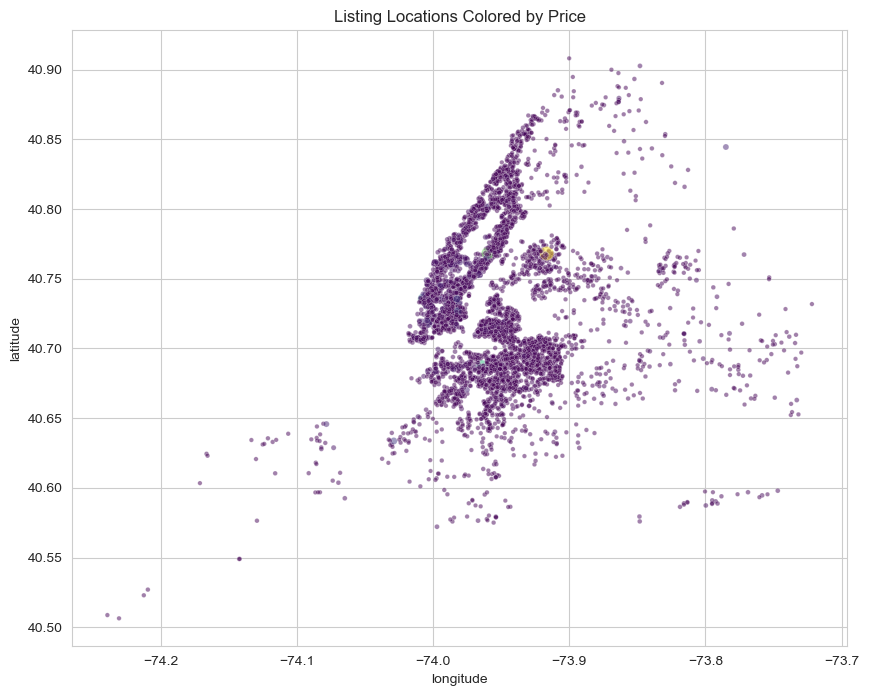

In [87]:
#8. Geographic scatter (lat/long colored by price)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df.sample(5000), x='longitude', y='latitude',
                 hue='price', size='price', palette='viridis',
                 alpha=0.5, sizes=(10, 100), legend=False)
plt.title('Listing Locations Colored by Price')
plt.savefig('geo_price_map.png', dpi=150)
plt.show()

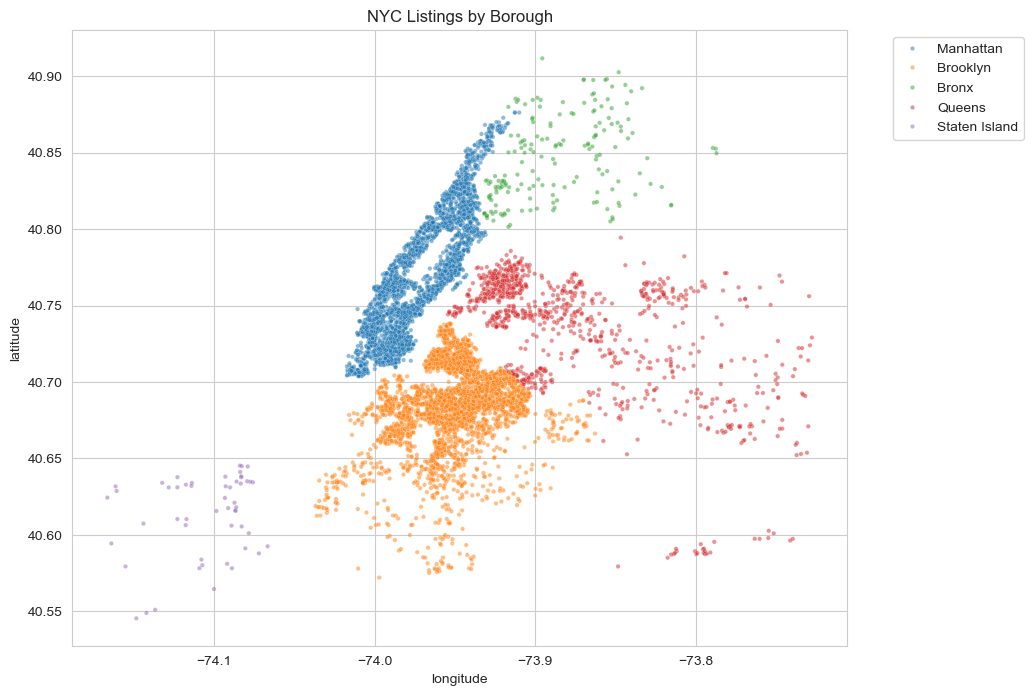

In [89]:
# 9. Geographic scatter colored by borough (cleaner categorical view)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df.sample(8000), x='longitude', y='latitude',
                 hue='neighbourhood_group', alpha=0.5, s=10)
plt.title('NYC Listings by Borough')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('geo_borough_map.png', dpi=150)
plt.show()

count    48884.000000
mean         7.029887
std         20.512224
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

Listings requiring 30+ min nights: 4505


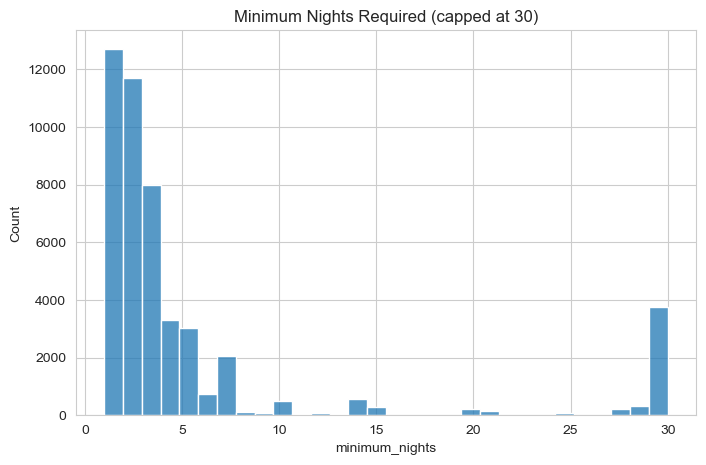

In [91]:
#10. Minimum nights distribution (often has extreme outliers) 
print(df['minimum_nights'].describe())
print(f"\nListings requiring 30+ min nights: {(df['minimum_nights'] >= 30).sum()}")

plt.figure(figsize=(8, 5))
sns.histplot(df[df['minimum_nights'] <= 30]['minimum_nights'], bins=30)
plt.title('Minimum Nights Required (capped at 30)')
plt.savefig('minimum_nights_dist.png', dpi=150)
plt.show()

price_per_night_category  Budget   Mid  High  Luxury  Premium
neighbourhood_group                                          
Bronx                       34.0  45.2  16.6     3.5      0.6
Brooklyn                    17.8  40.8  31.2     9.1      1.1
Manhattan                    4.8  27.2  40.6    23.8      3.6
Queens                      25.9  46.5  21.9     5.2      0.5
Staten Island               27.9  44.5  20.9     5.1      1.6


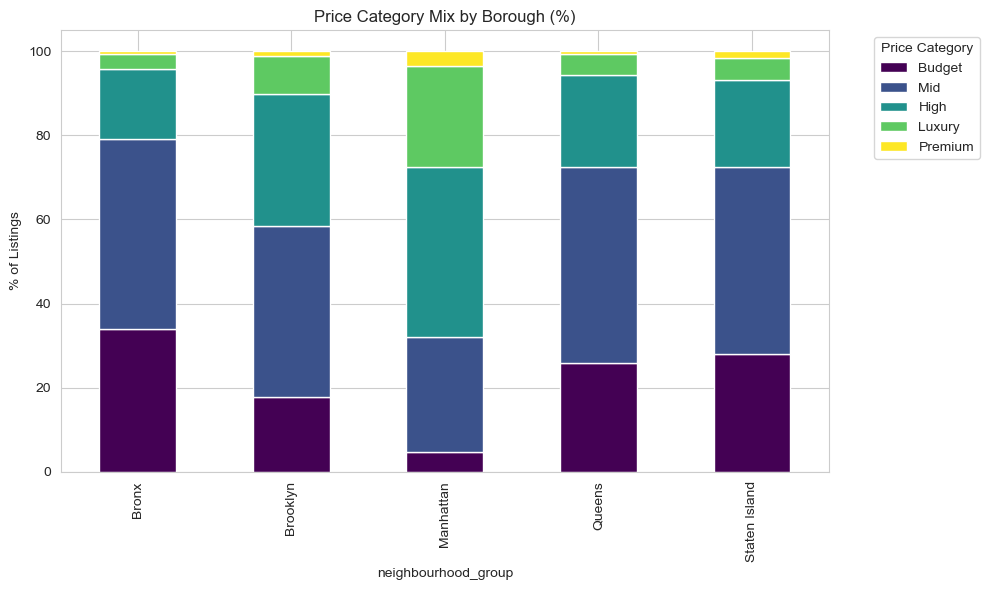

In [93]:
# 11. Price category breakdown by borough (using your earlier bucket) 
price_borough = pd.crosstab(df['neighbourhood_group'], df['price_per_night_category'], normalize='index') * 100
print(price_borough.round(1))

price_borough.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Price Category Mix by Borough (%)')
plt.ylabel('% of Listings')
plt.legend(title='Price Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('price_category_by_borough.png', dpi=150)
plt.show()

In [95]:
# 12. Review activity: which boroughs get the most reviews?
print(df.groupby('neighbourhood_group')['number_of_reviews'].agg(['sum', 'mean', 'median']))

                        sum       mean  median
neighbourhood_group                           
Bronx                 28316  25.977982     9.0
Brooklyn             486252  24.197661     6.0
Manhattan            454569  20.986565     4.0
Queens               156950  27.700318     7.0
Staten Island         11541  30.941019    12.0


In [97]:
#13. Top 10 busiest host
top_hosts = df.groupby('host_id').agg(
    listings=('id', 'count'),
    avg_price=('price', 'mean'),
    total_reviews=('number_of_reviews', 'sum')
).sort_values('listings', ascending=False).head(10)
print(top_hosts)

           listings   avg_price  total_reviews
host_id                                       
219517861       327  253.195719           1281
107434423       232  303.150862             29
30283594        121  277.528926             65
137358866       103   43.825243             87
16098958         96  208.958333            138
12243051         96  213.031250             43
61391963         91  146.241758            417
22541573         87  215.436782             55
200380610        65  290.230769              1
7503643          52  149.192308            242


In [99]:
df.to_excel('AB_NYC_2019_cleaned.xlsx', index=False, sheet_name='Cleaned Data')

In [103]:
import os
print(os.getcwd())

C:\Users\22257906\Downloads
